# LSB Watermark Benchmark (Class-Based)

This notebook is simplified and fully aligned with `lsb.model.WatermarkModel`.

It provides:
- A clean benchmark loop (encode -> attack -> decode)
- Attacks with geometric transforms using `order=0`
- BER and timing summaries
- Per-attack diagnostics: attacked image, extracted LSB, synchronized LSB, and synchronized-vs-reference overlay

## 1. Setup

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from skimage import data
from skimage.io import imread
from skimage.util import img_as_ubyte, img_as_float64, random_noise
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.transform import rotate, rescale, resize, warp, ProjectiveTransform
from skimage.filters import gaussian
from skimage.exposure import adjust_gamma

warnings.filterwarnings("ignore")

ROOT = Path(".")
IMG_DIR = ROOT / "img"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from spatial.model import WatermarkModel
from utils.patch import build_reference_patch
from utils.sync import synchronise

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.grid": False,
})

print("Setup complete.")

Setup complete.


## 2. Load Images

In [2]:
def load_images(directory: Path, exclude_folder: str = "_old") -> dict[str, np.ndarray]:
    exts = {".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif"}
    out: dict[str, np.ndarray] = {}

    if not directory.exists():
        return out

    for p in sorted(directory.rglob("*")):
        if exclude_folder in p.parts:
            continue
        if p.suffix.lower() not in exts:
            continue
        arr = imread(str(p))
        if arr.ndim == 3 and arr.shape[2] == 4:
            arr = arr[..., :3]
        out[p.stem] = img_as_ubyte(arr)

    return out


def show_gallery(images: dict[str, np.ndarray], max_cols: int = 4) -> None:
    if not images:
        print("No images to display.")
        return
    n = len(images)
    cols = min(max_cols, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.0 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, (name, img) in zip(axes, images.items()):
        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(name)
        ax.axis("off")
    for ax in axes[len(images):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


images = load_images(IMG_DIR)

if not images:
    print("No images found in img/. Using skimage fallback images.")
    images = {
        "camera": img_as_ubyte(data.camera()),
        "astronaut": img_as_ubyte(data.astronaut()),
    }

print(f"Loaded {len(images)} image(s): {list(images.keys())}")

Loaded 6 image(s): ['ICIP_GC1_JPT_WM_R062', 'airplane', 'baboon', 'cameraman', 'man', 'tangled']


## 3. Helpers

In [3]:
def make_watermark(n_bits: int, seed: int = SEED) -> np.ndarray:
    return np.random.default_rng(seed).integers(0, 2, n_bits, dtype=np.uint8)


def to_u8(img: np.ndarray) -> np.ndarray:
    return img_as_ubyte(np.clip(img_as_float64(img), 0.0, 1.0))


def extract_lsb_plane(img: np.ndarray) -> np.ndarray:
    img_u8 = to_u8(img)
    channel = img_u8[..., 1] if img_u8.ndim == 3 else img_u8
    return (channel & np.uint8(1)).astype(np.uint8)


def bit_error_rate(original: np.ndarray, decoded: np.ndarray) -> float:
    a = np.asarray(original, dtype=np.uint8).reshape(-1)
    b = np.asarray(decoded, dtype=np.uint8).reshape(-1)
    n = min(len(a), len(b))
    if n == 0:
        return 1.0
    return float(np.mean(a[:n] != b[:n]))


def compute_psnr(reference: np.ndarray, distorted: np.ndarray) -> float:
    try:
        return float(psnr(to_u8(reference), to_u8(distorted), data_range=255))
    except Exception:
        return float("inf")


print("Helpers ready.")

Helpers ready.


## 4. Attacks (geometric transforms use order=0)

In [4]:
def attack_none(img: np.ndarray) -> np.ndarray:
    return to_u8(img)


def attack_rotate(img: np.ndarray, angle: float = 15.0) -> np.ndarray:
    out = rotate(
        img_as_float64(img),
        angle=angle,
        order=0,
        mode="reflect",
        preserve_range=True,
    )
    return to_u8(out)


def attack_scale(img: np.ndarray, factor: float = 0.85) -> np.ndarray:
    img_f = img_as_float64(img)
    ch_axis = 2 if img_f.ndim == 3 else None
    scaled = rescale(
        img_f,
        factor,
        order=0,
        mode="reflect",
        preserve_range=True,
        anti_aliasing=False,
        channel_axis=ch_axis,
    )
    restored = resize(
        scaled,
        img.shape[:2] if img.ndim == 2 else img.shape,
        order=0,
        mode="reflect",
        preserve_range=True,
        anti_aliasing=False,
    )
    return to_u8(restored)


def attack_crop(img: np.ndarray, fraction: float = 0.10) -> np.ndarray:
    h, w = img.shape[:2]
    dy = max(1, int(h * fraction))
    dx = max(1, int(w * fraction))
    cropped = img[dy:h - dy, dx:w - dx]
    if cropped.size == 0:
        return to_u8(img)
    restored = resize(
        img_as_float64(cropped),
        img.shape[:2] if img.ndim == 2 else img.shape,
        order=0,
        mode="reflect",
        preserve_range=True,
        anti_aliasing=False,
    )
    return to_u8(restored)


def attack_shift(img: np.ndarray, shift: int = 10) -> np.ndarray:
    return np.roll(to_u8(img), shift=(shift, shift), axis=(0, 1))


def attack_perspective(img: np.ndarray, strength: float = 0.05) -> np.ndarray:
    h, w = img.shape[:2]
    d = strength * min(h, w)
    src = np.array([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]], dtype=float)
    dst = src + np.array([[-d, -d], [d, -d], [-d, d], [d, d]])
    tform = ProjectiveTransform()
    tform.estimate(src, dst)
    warped = warp(
        img_as_float64(img),
        inverse_map=tform.inverse,
        output_shape=(h, w),
        order=0,
        mode="edge",
        preserve_range=True,
    )
    return to_u8(warped)


def attack_resize_roundtrip(img: np.ndarray, factor: float = 0.5) -> np.ndarray:
    h, w = img.shape[:2]
    small_shape = (max(1, int(h * factor)), max(1, int(w * factor)))
    if img.ndim == 3:
        small_shape = (small_shape[0], small_shape[1], img.shape[2])
    small = resize(
        img_as_float64(img),
        small_shape,
        order=0,
        mode="reflect",
        preserve_range=True,
        anti_aliasing=False,
    )
    restored = resize(
        small,
        img.shape[:2] if img.ndim == 2 else img.shape,
        order=0,
        mode="reflect",
        preserve_range=True,
        anti_aliasing=False,
    )
    return to_u8(restored)


def attack_noise(img: np.ndarray, var: float = 0.005) -> np.ndarray:
    noisy = random_noise(img_as_float64(img), mode="gaussian", var=var, rng=SEED)
    return to_u8(noisy)


def attack_blur(img: np.ndarray, sigma: float = 2.0) -> np.ndarray:
    out = gaussian(
        img_as_float64(img),
        sigma=sigma,
        channel_axis=2 if img.ndim == 3 else None,
        preserve_range=True,
    )
    return to_u8(out)


def attack_gamma(img: np.ndarray, gamma: float = 1.8) -> np.ndarray:
    return to_u8(adjust_gamma(img_as_float64(img), gamma=gamma))


def attack_brightness(img: np.ndarray, offset: float = 0.15) -> np.ndarray:
    return to_u8(np.clip(img_as_float64(img) + offset, 0.0, 1.0))


def attack_jpeg(img: np.ndarray, quality: int = 50) -> np.ndarray:
    import io
    try:
        from PIL import Image as PILImage
        buf = io.BytesIO()
        PILImage.fromarray(to_u8(img)).save(buf, format="JPEG", quality=quality)
        buf.seek(0)
        return to_u8(np.array(PILImage.open(buf)))
    except Exception:
        fallback = gaussian(img_as_float64(img), sigma=1 + (100 - quality) / 50)
        return to_u8(fallback)


ATTACKS: dict[str, callable] = {
    "none": attack_none,
    "rotate_15": lambda x: attack_rotate(x, angle=15.0),
    "scale_0.85": lambda x: attack_scale(x, factor=0.85),
    "crop_10pct": lambda x: attack_crop(x, fraction=0.10),
    "shift_10": lambda x: attack_shift(x, shift=10),
    "perspective_5pct": lambda x: attack_perspective(x, strength=0.05),
    "resize_x0.5": lambda x: attack_resize_roundtrip(x, factor=0.5),
    "noise_var0.005": lambda x: attack_noise(x, var=0.005),
    "blur_s2": lambda x: attack_blur(x, sigma=2.0),
    "gamma_1.8": lambda x: attack_gamma(x, gamma=1.8),
    "brightness_plus": lambda x: attack_brightness(x, offset=0.15),
    "jpeg_q50": lambda x: attack_jpeg(x, quality=50),
}

print(f"{len(ATTACKS)} attacks registered.")

12 attacks registered.


Model initialized.
Image loaded.
Watermark generated.
Image watermarked.


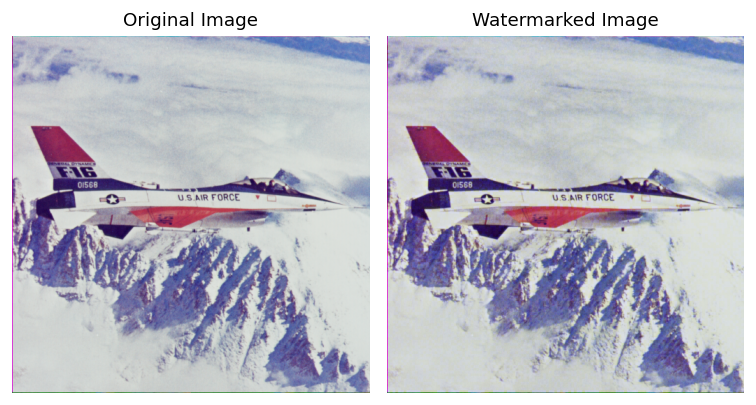

Range channel: 43 to 243
Range denoised: 0.1808063291669284 to 0.9414277946030803
Denoised dtype: float64
Range residual: -0.1422900024207211 to 0.13251028806584375


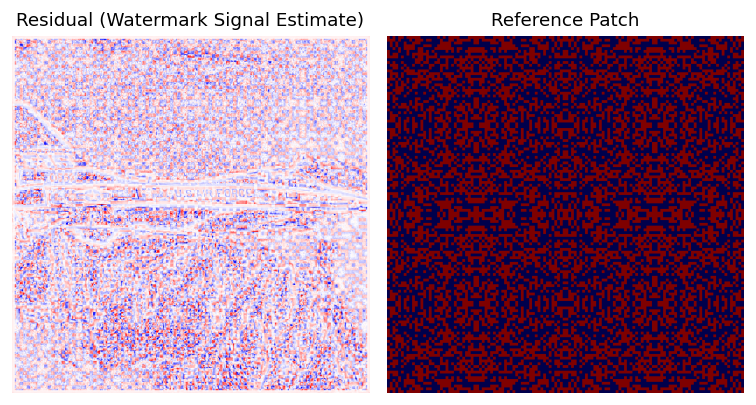

In [5]:
import skimage
from scipy.signal import wiener
from utils.patch import *

from utils.sync import *

def expand_peaks(image , expansion_size=3):
    expanded = np.zeros_like(image)
    peaks = np.argwhere(image > 0)
    for peak in peaks:
        x, y = peak
        expanded[ max (0, x-expansion_size): min (image.shape[0], x+expansion_size+1), max (0, y-expansion_size): min (image.shape[1], y+expansion_size+1)] = 1
    return expanded


model = WatermarkModel(nms_size_ac=2*5*32, upsample_factor=4)
print("Model initialized.")

image = data.astronaut()
image = images["airplane"]
print("Image loaded.")

watermark = make_watermark(model.msg_length)
print("Watermark generated.")

watermarked = model.encode(image, watermark)
print("Image watermarked.")

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(watermarked)
plt.title("Watermarked Image")
plt.axis("off")
plt.tight_layout()
plt.show()

img_f = skimage.img_as_float(watermarked).astype(np.float32)

img_f = attack_crop(img_f)  # Example attack: rotate by 15 degrees
H, W  = img_f.shape[:2]

channel = model._get_channel(img_f)   # (H, W)

# 3. Wiener denoising — noise power ≈ mean energy of the watermark signal
print("Range channel:", channel.min(), "to", channel.max())
channel = skimage.img_as_float(channel)
ref = build_reference_patch_bipolar((H, W), model.patch_size, model.key, model.tile_mode, model.upsample_factor).astype(float)
nvf = model._compute_nvf(channel)
strength = model._embedding_strength(nvf)
ref_weighted = ref * strength


denoised    = wiener(channel, mysize=9, noise=np.var(ref_weighted))

print("Range denoised:", denoised.min(), "to", denoised.max())
print("Denoised dtype:", denoised.dtype)
# 4. Residual ≈ watermark signal (float32, shape (H, W))
residual = (channel - denoised)

print("Range residual:", residual.min(), "to", residual.max())

reference = build_reference_patch((H, W), model.patch_size, model.key, model.tile_mode, model.upsample_factor).astype(float) * 2 - 1  # Convert {0, 1} to {-1, 1}

reference = cv2.normalize(reference, None, alpha=-1.0, beta=1.0, norm_type=cv2.NORM_MINMAX).astype(np.float32)

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(residual, cmap="seismic", norm=mcolors.CenteredNorm())
plt.title("Residual (Watermark Signal Estimate)")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(reference, cmap="seismic", norm=mcolors.CenteredNorm())
plt.title("Reference Patch")
plt.axis("off")
plt.tight_layout()
plt.show()



Range of Residual AC: -0.1422900024207211 to 0.13251028806584375
Range of Reference Patch: -1.0 to 1.0
Range of Residual AC: -31807.991689394614 to 262143.74896706425
Range of Reference AC: -18741.6627036124 to 262144.0140619852


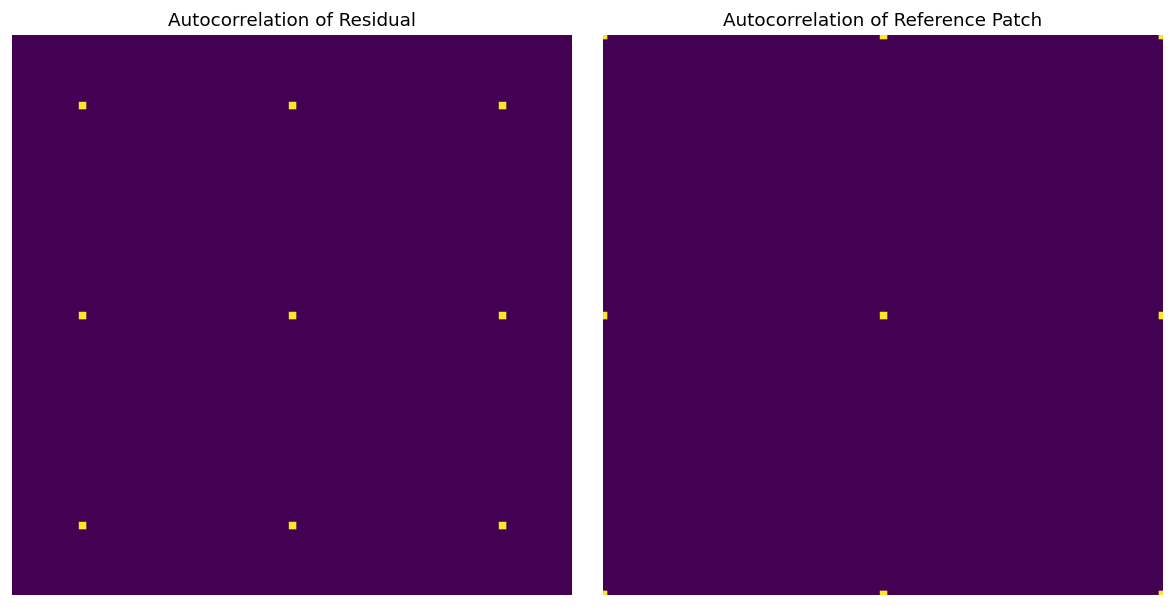

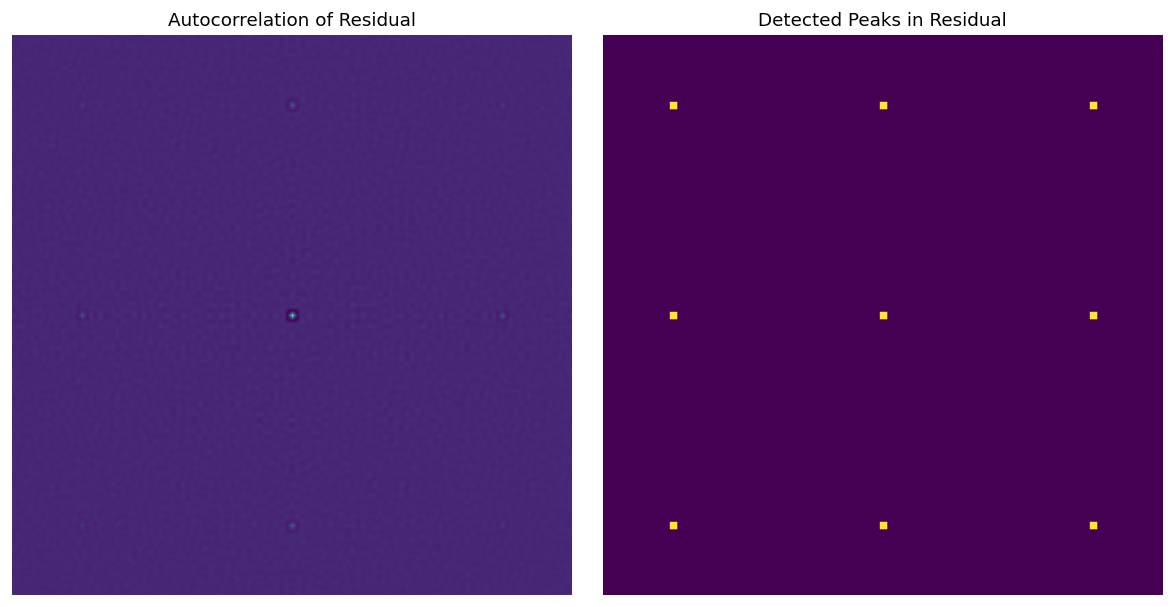

In [6]:
# Autocorrelation of the residual should reveal peaks at the patch periodicity if the watermark is present
print("Range of Residual AC:", residual.min(), "to", residual.max())
print("Range of Reference Patch:", reference.min(), "to", reference.max())
residual_ac = correlation_fft(residual, residual) # Autocorrelation of the residual
ref_ac = correlation_fft(reference, reference)

def detect_peaks_blockwise(img, block_size=32, overlap=0.5, percentile=95):
    h, w = img.shape
    step = int(block_size * (1 - overlap))
    k = 15  # Threshold factor for maximum value
    
    peaks = np.zeros_like(img, dtype=np.uint8)
    
    for y in range(0, h - block_size, step):
        for x in range(0, w - block_size, step):
            
            block = img[y:y+block_size, x:x+block_size]
            
            # seuil robuste
            thresh = np.percentile(block, percentile)
            
            mask = block >= thresh
            
            if np.sum(mask) == 0:
                continue
            
            # maximum réel
            max_val = np.max(block)

            if max_val < np.mean(block) + k*np.std(block):
                continue
            max_pos = np.argwhere(block == max_val)
            
            # centre du max (si plusieurs pixels)
            cy, cx = max_pos.mean(axis=0).astype(int)
            
            peaks[y+cy, x+cx] = 1
    
    return peaks

from scipy.spatial import KDTree

def remove_outliers(points, radius=20, min_neighbors=2):
    tree = KDTree(points)
    
    keep = []
    for i, p in enumerate(points):
        neighbors = tree.query_ball_point(p, radius)
        
        if len(neighbors) > min_neighbors:
            keep.append(p)
    
    return np.array(keep)

print("Range of Residual AC:", residual_ac.min(), "to", residual_ac.max())
print("Range of Reference AC:", ref_ac.min(), "to", ref_ac.max())

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(expand_peaks(non_maximum_suppression(residual_ac, size=model.nms_size_ac)), cmap="viridis")
plt.title("Autocorrelation of Residual")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(expand_peaks(non_maximum_suppression(ref_ac, size=model.nms_size_ac)), cmap="viridis")
plt.title("Autocorrelation of Reference Patch")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(residual_ac, cmap="viridis")
plt.title("Autocorrelation of Residual")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(expand_peaks(non_maximum_suppression(residual_ac, size=model.nms_size_ac)), cmap="viridis")
plt.title("Detected Peaks in Residual")
plt.axis("off")
plt.tight_layout()
plt.show()


Selected Residual Peaks:
 [[256. 256.]
 [ 64. 256.]
 [256.  64.]]
Selected Reference Peaks:
 [[256. 256.]
 [511. 256.]
 [256. 511.]]
Estimated transformation:
 [[  0.        -1.328125 596.      ]
 [ -1.328125   0.       596.      ]]


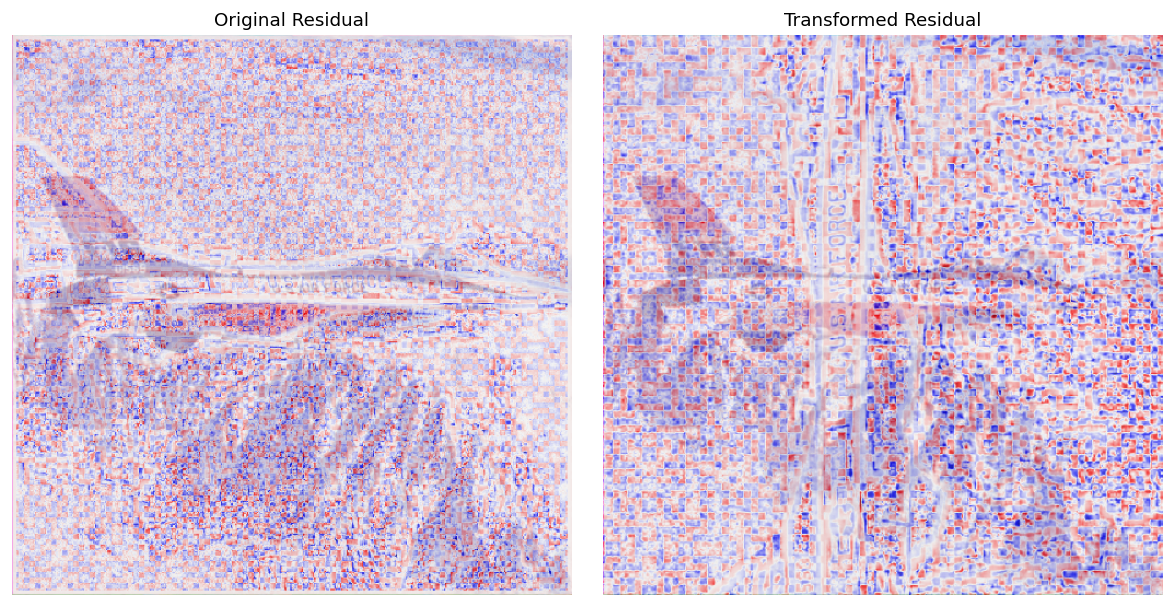

In [7]:
import cv2
import numpy as np


# def estimate_affine(
#     img_ac: np.ndarray,
#     ref_ac: np.ndarray,
#     nms_size: int = 31,
#     n_peaks: int = 15
# ) -> np.ndarray:
#     """
#     Robust affine estimation (rotation + scale + translation)
#     invariant to translation via FFT magnitude centering.
#     """

#     # ---- 1. Peak detection ----
#     img_peaks = non_maximum_suppression(img_ac, nms_size)
#     ref_peaks = non_maximum_suppression(ref_ac, nms_size)

#     # ---- 2. Binarization ----
#     img_bin = (img_peaks > 0).astype(np.float32)
#     ref_bin = (ref_peaks > 0).astype(np.float32)

#     h, w = img_bin.shape
#     center = (w / 2.0, h / 2.0)

#     # ---- 3. Windowing ----
#     window = cv2.createHanningWindow((w, h), cv2.CV_32F)
#     img_win = img_bin * window
#     ref_win = ref_bin * window

#     # ---- 4. FFT ----
#     f1 = cv2.dft(img_ac, flags=cv2.DFT_COMPLEX_OUTPUT)
#     f2 = cv2.dft(ref_ac, flags=cv2.DFT_COMPLEX_OUTPUT)

#     mag1 = cv2.magnitude(f1[..., 0], f1[..., 1])
#     mag2 = cv2.magnitude(f2[..., 0], f2[..., 1])

#     # ---- 🔥 5. CRUCIAL: center spectrum ----
#     mag1 = np.fft.fftshift(mag1)
#     mag2 = np.fft.fftshift(mag2)

#     # avoid log issues
#     mag1 += 1e-8
#     mag2 += 1e-8

#     # ---- 6. Log-polar ----
#     M_scale = w / np.log(w)

#     lp1 = cv2.logPolar(mag1, center, M_scale, cv2.INTER_LINEAR)
#     lp2 = cv2.logPolar(mag2, center, M_scale, cv2.INTER_LINEAR)

#     # ---- 7. Rotation + scale ----
#     (shift, _) = cv2.phaseCorrelate(lp1, lp2)

#     angle = - (shift[1] * 360.0) / lp1.shape[0]
#     scale = np.exp(shift[0] / M_scale)

#     print(f"Estimated angle: {angle:.2f} degrees")
#     print(f"Estimated scale: {scale:.4f}x")

#     # ---- 8. Warp (rotation + scale) ----
#     M_rs = cv2.getRotationMatrix2D(center, angle, scale)
#     # Warp magnitude instead of binary image
#     # ---- 8. Warp full signal (NOT binary) ----
#     img_rs = cv2.warpAffine(
#         img_ac.astype(np.float32),
#         M_rs,
#         (w, h),
#         flags=cv2.INTER_LINEAR
#     )

#     ref_f = ref_ac.astype(np.float32)

#     # ---- 9. Cross-correlation via FFT ----
#     corr = cv2.matchTemplate(
#         img_rs,
#         ref_f,
#         method=cv2.TM_CCORR_NORMED
#     )

#     # ---- 10. Peak detection ----
#     _, _, _, max_loc = cv2.minMaxLoc(corr)

#     tx, ty = max_loc  # (x, y)

#     # ---- 11. Compose affine ----
#     M = M_rs.copy()
#     M[0, 2] += tx
#     M[1, 2] += ty

#     return M.astype(np.float32)

# Select peaks in the autocorrelation
selected_residual_peaks = non_maximum_suppression(residual_ac, size=model.nms_size_ac)
selected_reference_peaks = non_maximum_suppression(ref_ac, size=model.nms_size_ac)

img_pts = detect_interest_points(selected_residual_peaks)
ref_pts = detect_interest_points(selected_reference_peaks)

print("Selected Residual Peaks:\n", img_pts)
print("Selected Reference Peaks:\n", ref_pts)

transformation = estimate_affine(residual_ac, ref_ac, nms_size=model.nms_size_ac)

print("Estimated transformation:\n", transformation)

transformed = correct_affine(residual, transformation)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(residual, cmap="seismic", norm=mcolors.CenteredNorm())
plt.imshow(image, alpha=0.3)  # Overlay original image for reference
plt.title("Original Residual")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(transformed[:, ::-1], cmap="seismic", norm=mcolors.CenteredNorm())
plt.imshow(image, alpha=0.3)  # Overlay original image for reference
plt.title("Transformed Residual")
plt.axis("off")
plt.tight_layout()
plt.show()


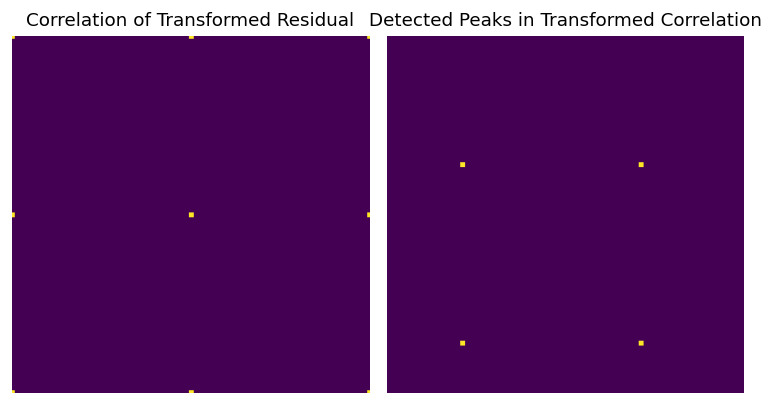

Center peak in transformed correlation: (184.0, 364.0)
Center peak in reference AC: (256.0, 256.0)
Estimated translation:
 [[   1.    0. -108.]
 [   0.    1.   72.]]


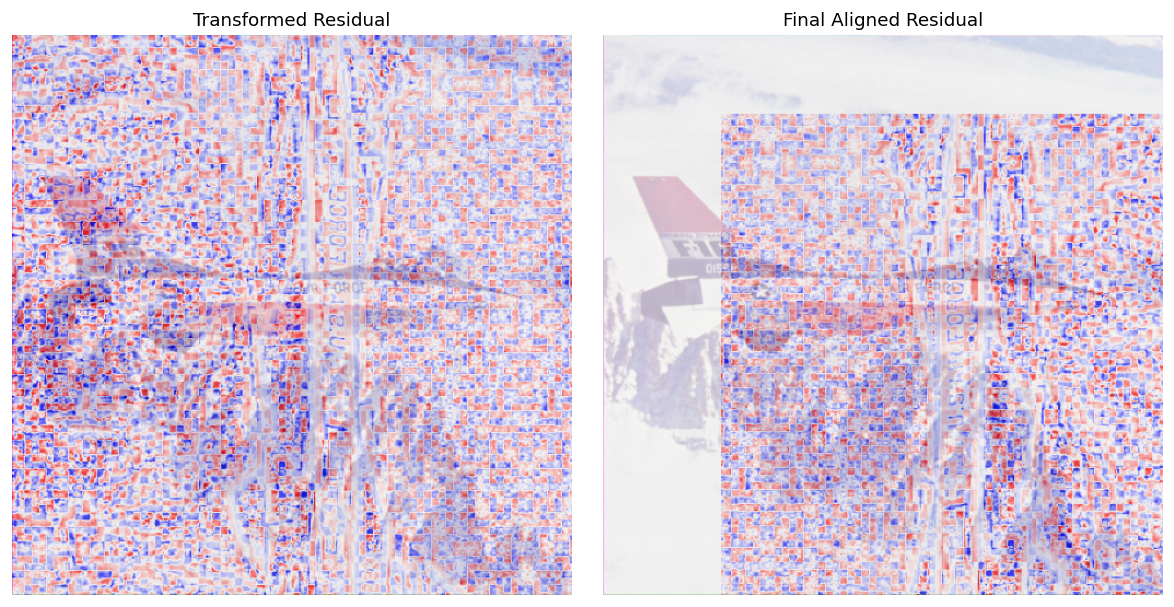

In [8]:
transformed_correlation = correlation_fft(transformed[:, ::-1], reference)

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(expand_peaks(non_maximum_suppression(ref_ac, size=model.nms_size_ac)), cmap="viridis")
plt.title("Correlation of Transformed Residual")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(expand_peaks(non_maximum_suppression(transformed_correlation, size=model.nms_size_ac)), cmap="viridis")
plt.title("Detected Peaks in Transformed Correlation")
plt.axis("off")
plt.tight_layout()
plt.show()



cx, cy = get_center_peak(non_maximum_suppression(transformed_correlation, size=model.nms_size_ac))
ref_x, ref_y = get_center_peak(non_maximum_suppression(ref_ac, size=model.nms_size_ac))

print(f"Center peak in transformed correlation: ({cx}, {cy})")
print(f"Center peak in reference AC: ({ref_x}, {ref_y})")


translation = np.array([[1, 0, ref_y - cy],
                        [0, 1, ref_x - cx]], dtype=np.float32)

print("Estimated translation:\n", translation)

transformed_final = correct_affine(transformed, translation)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(transformed, cmap="seismic", norm=mcolors.CenteredNorm())
plt.imshow(image, alpha=0.3)  # Overlay original image for reference
plt.title("Transformed Residual")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(transformed_final[:, ::-1], cmap="seismic", norm=mcolors.CenteredNorm())
plt.imshow(image, alpha=0.3)  # Overlay original image for reference
plt.title("Final Aligned Residual")
plt.axis("off")
plt.tight_layout()
plt.show()



Range of Blocks: 0.0 to 1.0
Range of Reference Block: 0.0 to 1.0


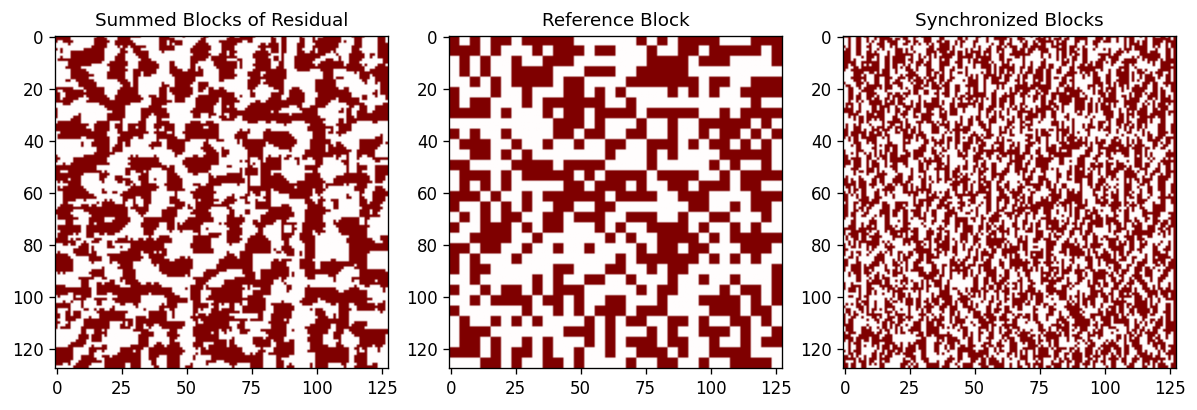

In [9]:
sync_result = synchronise(residual, patch_size=model.patch_size, key=model.key, tile_mode=model.tile_mode, upsample_factor=model.upsample_factor)

blocks = sum_blocks(transformed_final, model.patch_size, model.tile_mode, model.upsample_factor)
blocks[blocks <= 0] = 0  # Only keep positive correlations
blocks[blocks > 0] = 1  # Binarize for visualization
ref_block = upsample_patch(generate_base_patch(model.patch_size, model.key), factor=model.upsample_factor).astype(float)
print("Range of Blocks:", blocks.min(), "to", blocks.max())
print("Range of Reference Block:", ref_block.min(), "to", ref_block.max())

blocks_sync = sum_blocks(sync_result[2], model.patch_size, model.tile_mode, model.upsample_factor)
blocks_sync[blocks_sync <= 0] = 0  # Only keep positive correlations
blocks_sync[blocks_sync > 0] = 1


plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(blocks, cmap="seismic", norm=mcolors.CenteredNorm())
plt.title("Summed Blocks of Residual")
plt.subplot(1, 3, 2)
plt.imshow(ref_block, cmap="seismic", norm=mcolors.CenteredNorm())
plt.title("Reference Block")
plt.subplot(1, 3, 3)
plt.imshow(blocks_sync, cmap="seismic", norm=mcolors.CenteredNorm())
plt.title("Synchronized Blocks")
plt.tight_layout()
plt.show()

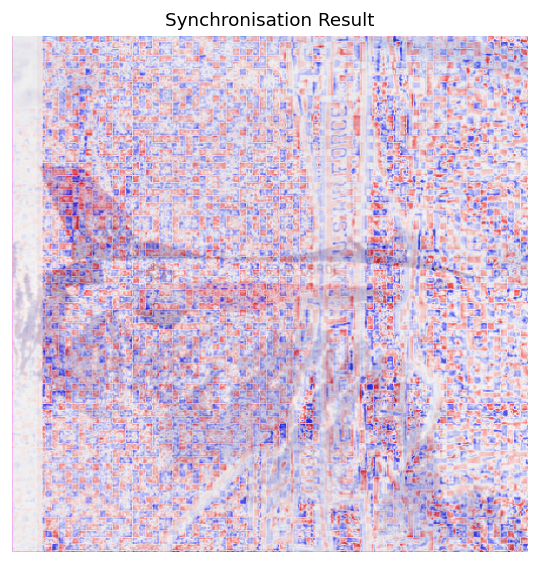

In [10]:
sync_result = synchronise(residual, patch_size=model.patch_size, nms_size_ac=model.nms_size_ac, key=model.key, tile_mode=model.tile_mode, upsample_factor=model.upsample_factor)

plt.figure()
plt.imshow(sync_result[1], cmap="seismic", norm=mcolors.CenteredNorm())
plt.imshow(image, alpha=0.3)  # Overlay original image for reference
plt.imshow(transformed_final, alpha=0.1, cmap="seismic", norm=mcolors.CenteredNorm())  # Overlay transformed residual for comparison
plt.title("Synchronisation Result")
plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
watermark_extracted = model.decode(img_f)
    # watermark_extracted_sync, _ = extract_bits_from_spatial(sync_result[::-1], model.patch_size, model.msg_length, model.key, model.upsample_factor)
    # watermark_extracted_corrected, _ = extract_bits_from_spatial(transformed_final[:, ::-1], model.patch_size, model.msg_length, model.key, model.upsample_factor)

print("BER:", bit_error_rate(watermark, watermark_extracted))
# print("BER (Synchronised):", bit_error_rate(watermark, watermark_extracted_sync))
# print("BER (Corrected):", bit_error_rate(watermark, watermark_extracted_corrected))

BER: 0.5625


## 5. Model + Benchmark

In [12]:
MESSAGE_LENGTH = 32
watermark = make_watermark(MESSAGE_LENGTH, seed=SEED)

model = WatermarkModel(upsample_factor=4)


def run_benchmark(
    model: WatermarkModel,
    images: dict[str, np.ndarray],
    attacks: dict[str, callable],
    watermark: np.ndarray,
    verbose: bool = True,
) -> pd.DataFrame:
    records: list[dict] = []
    total = len(images) * len(attacks)
    done = 0

    for image_name, image in images.items():
        src = to_u8(image)

        t0 = time.perf_counter()
        wm_img = model.encode(src, watermark)
        encode_time = time.perf_counter() - t0
        psnr_embed = compute_psnr(src, wm_img)

        for attack_name, attack_fn in attacks.items():
            attacked = to_u8(attack_fn(wm_img))

            t1 = time.perf_counter()
            decoded = model.decode(attacked)
            decode_time = time.perf_counter() - t1

            decoded_bits = np.asarray(decoded, dtype=np.uint8).reshape(-1)
            n = min(len(watermark), len(decoded_bits))
            ber_val = bit_error_rate(watermark[:n], decoded_bits[:n])

            records.append({
                "image": image_name,
                "attack": attack_name,
                "ber": ber_val,
                "encode_time_s": encode_time,
                "decode_time_s": decode_time,
                "psnr_embed": psnr_embed,
                "psnr_attacked": compute_psnr(src, attacked),
            })

            done += 1
            if verbose:
                print(f"[{done:4d}/{total}] {image_name:<16s} {attack_name:<18s} BER={ber_val:.3f}", end="\r")

    if verbose:
        print()

    return pd.DataFrame(records)


results = run_benchmark(model, images, ATTACKS, watermark, verbose=True)
print(f"Collected {len(results)} records.")
display(results.head(10))

KeyboardInterrupt: 

## 6. Summary Visualizations

Mean BER by attack (lower is better):


,mean_ber,std_ber,mean_decode_ms,mean_psnr_attacked
attack,,,,
brightness_plus,0.005208,0.012758,1038.511383,16.562446
gamma_1.8,0.005208,0.012758,1038.259583,15.575961
none,0.005208,0.012758,1037.937383,35.439238
scale_0.85,0.005208,0.012758,1039.069550,30.446633
resize_x0.5,0.010417,0.016137,1036.649683,26.644781
noise_var0.005,0.010417,0.025516,1050.351967,22.924550
jpeg_q50,0.015625,0.026146,1043.043267,30.619191
blur_s2,0.036458,0.036533,1038.413683,27.726152
shift_10,0.072917,0.178609,1037.995517,16.903069


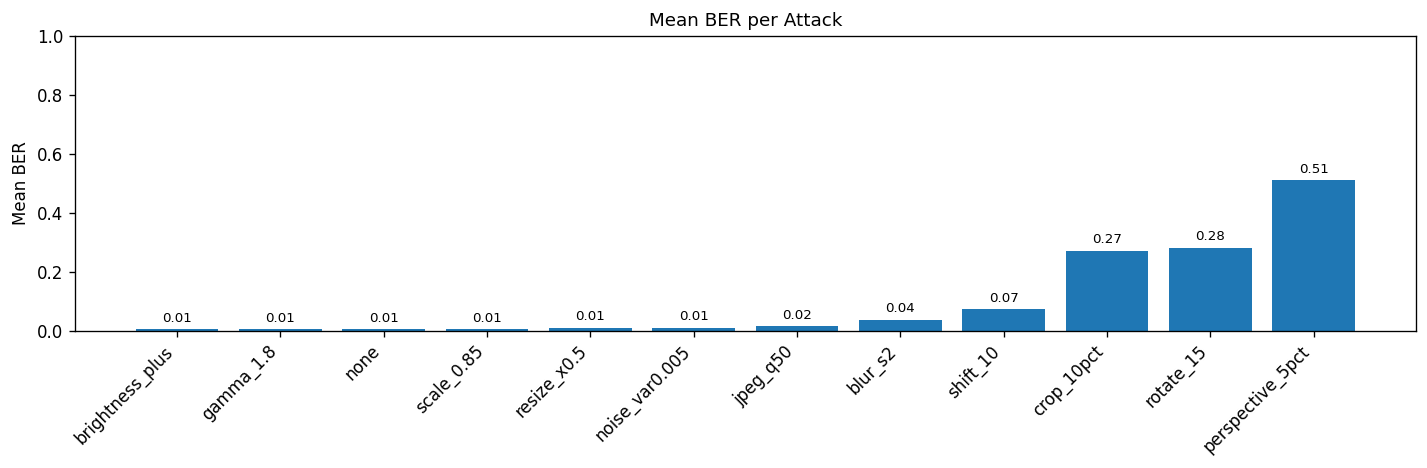

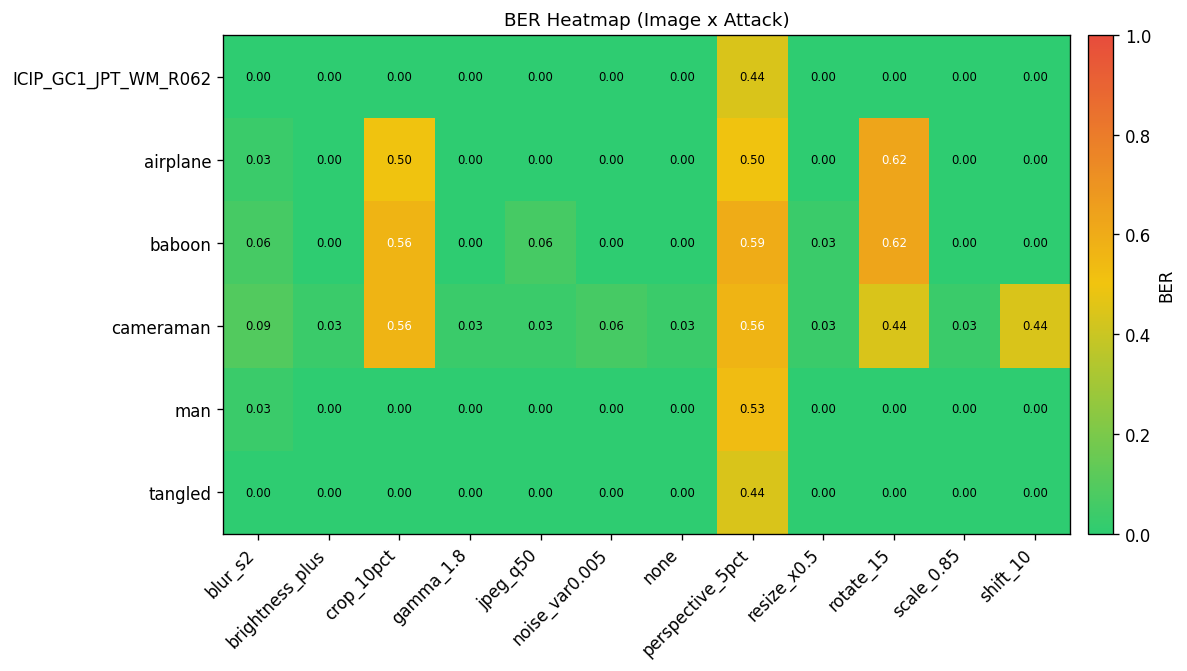

In [ ]:
attack_summary = (
    results.groupby("attack")
    .agg(
        mean_ber=("ber", "mean"),
        std_ber=("ber", "std"),
        mean_decode_ms=("decode_time_s", lambda x: x.mean() * 1000),
        mean_psnr_attacked=("psnr_attacked", "mean"),
    )
    .sort_values("mean_ber")
)

print("Mean BER by attack (lower is better):")
display(attack_summary)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(attack_summary.index, attack_summary["mean_ber"].values, color="#1f77b4")
ax.set_ylim(0, 1)
ax.set_ylabel("Mean BER")
ax.set_title("Mean BER per Attack")
ax.set_xticks(np.arange(len(attack_summary.index)))
ax.set_xticklabels(attack_summary.index, rotation=45, ha="right")
for b, v in zip(bars, attack_summary["mean_ber"].values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

pivot = results.pivot_table(index="image", columns="attack", values="ber", aggfunc="mean")

cmap = mcolors.LinearSegmentedColormap.from_list("ber_map", ["#2ecc71", "#f1c40f", "#e74c3c"])
fig, ax = plt.subplots(figsize=(max(10, 0.8 * pivot.shape[1]), max(2.5, 0.7 * pivot.shape[0] + 1.5)))
im = ax.imshow(pivot.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(np.arange(pivot.shape[1]))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(pivot.shape[0]))
ax.set_yticklabels(pivot.index)
ax.set_title("BER Heatmap (Image x Attack)")

for r in range(pivot.shape[0]):
    for c in range(pivot.shape[1]):
        value = float(pivot.values[r, c])
        ax.text(c, r, f"{value:.2f}", ha="center", va="center", color="white" if value > 0.55 else "black", fontsize=7)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="BER")
plt.tight_layout()
plt.show()

## 7. Per-Attack Diagnostics (Attacked / LSB / Synced / Reference Overlay)

For each attack, this visual check displays:
1. Attacked image
2. Extracted LSB plane
3. Synchronized LSB plane
4. Overlay of synchronized LSB on reference LSB

Diagnostic image: airplane


AttributeError: 'WatermarkModel' object has no attribute 'upsample_factor_rs'

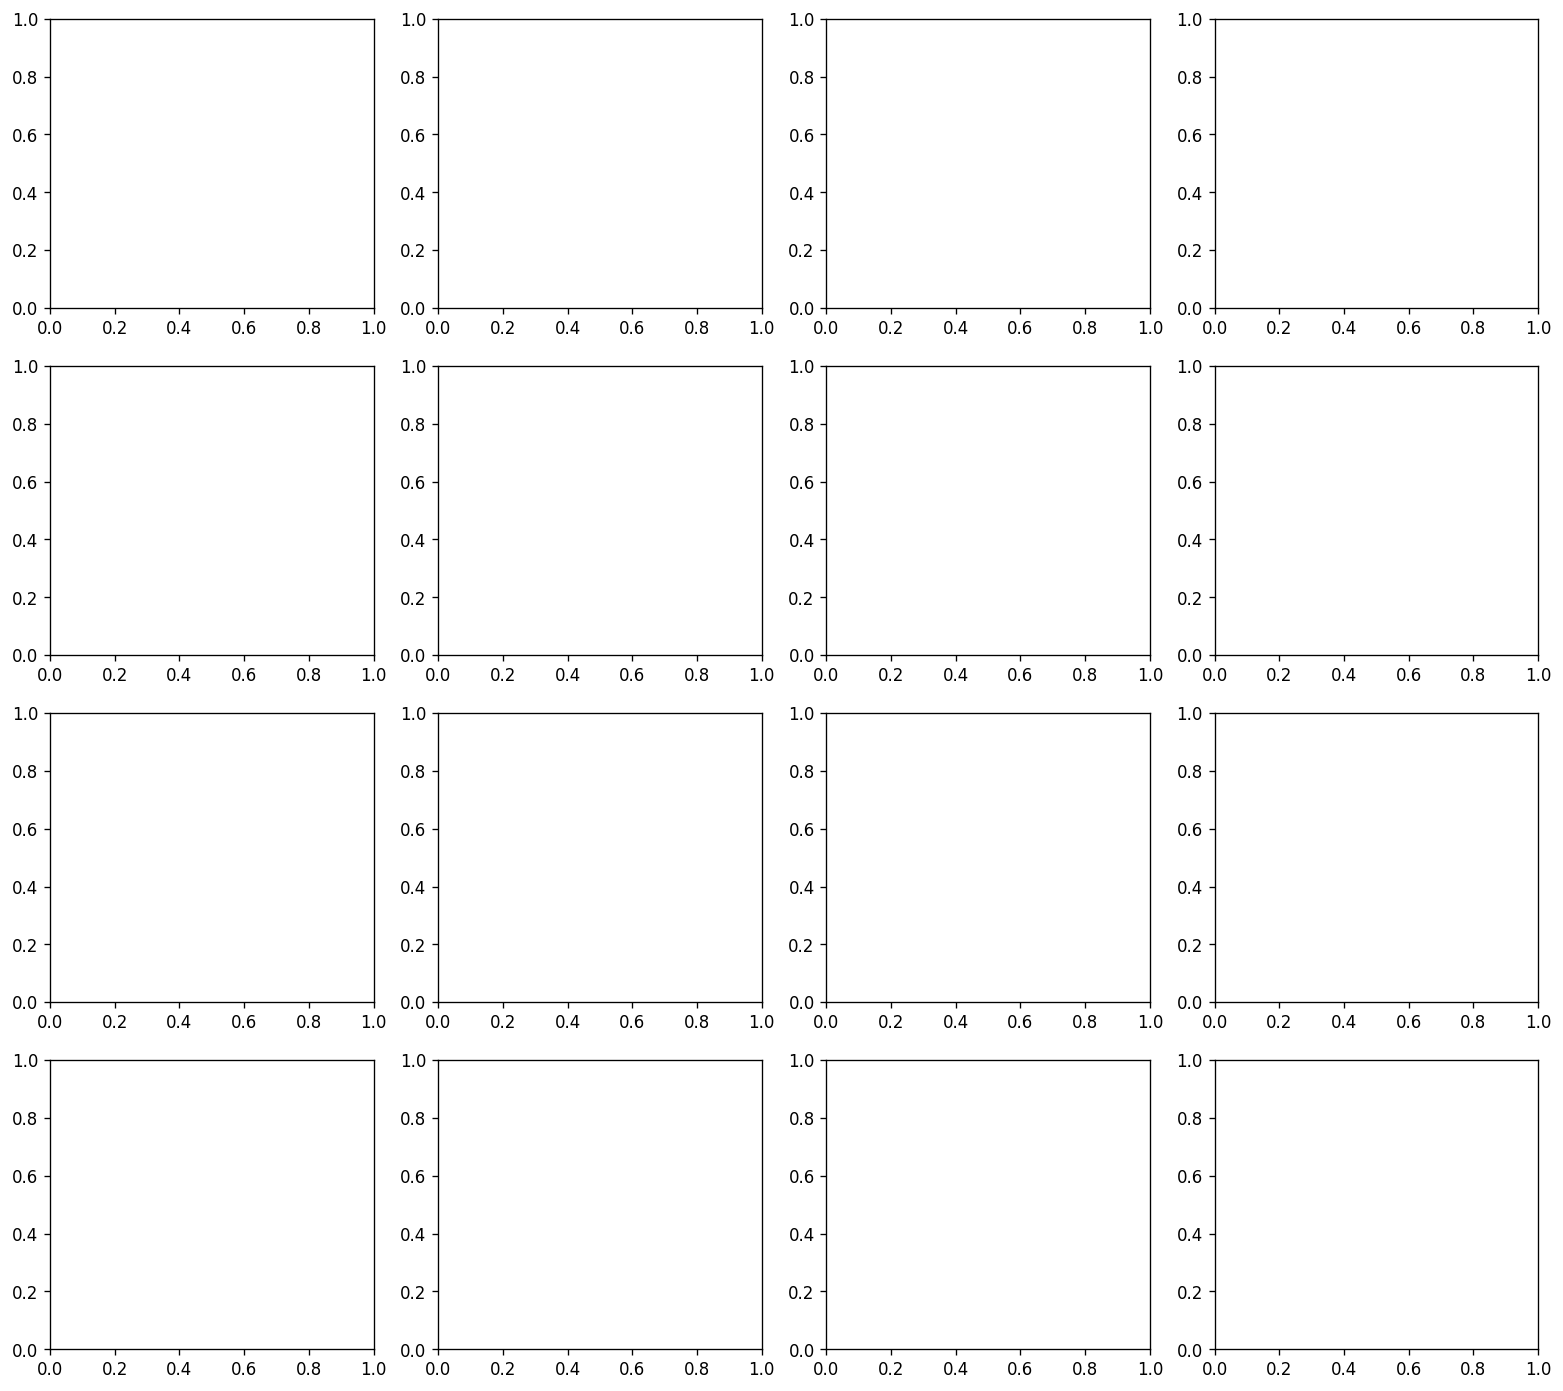

In [ ]:
def visualize_attack_diagnostics(
    model: WatermarkModel,
    source_image: np.ndarray,
    watermark: np.ndarray,
    attacks: dict[str, callable],
    image_name: str,
    rows_per_figure: int = 4,
) -> None:
    src = to_u8(source_image)
    wm_img = model.encode(src, watermark)
    attack_names = list(attacks.keys())

    for start in range(0, len(attack_names), rows_per_figure):
        names = attack_names[start:start + rows_per_figure]
        fig, axes = plt.subplots(len(names), 4, figsize=(16, 3.6 * len(names)))
        if len(names) == 1:
            axes = np.array([axes])

        for r, name in enumerate(names):
            attacked = to_u8(attacks[name](wm_img))
            attacked_lsb = extract_lsb_plane(attacked)

            synced_lsb = synchronise(
                attacked_lsb,
                upsample_factor_rs=model.upsample_factor_rs,
                upsample_factor_t=model.upsample_factor_t,
                patch_size=model.patch_size,
                key=model.key,
                tile_mode=model.tile_mode,
            )

            if synced_lsb.ndim != 2 or min(synced_lsb.shape) < 8:
                synced_lsb = attacked_lsb.astype(np.float32)

            reference_lsb = build_reference_patch(
                synced_lsb.shape,
                patch_size=model.patch_size,
                key=model.key,
                tile_mode=model.tile_mode,
            )

            synced_vis = np.nan_to_num(synced_lsb, nan=0.5)

            decoded_bits = np.asarray(model.decode(attacked), dtype=np.uint8).reshape(-1)
            n = min(len(watermark), len(decoded_bits))
            ber_val = bit_error_rate(watermark[:n], decoded_bits[:n])

            axes[r, 0].imshow(attacked, cmap="gray" if attacked.ndim == 2 else None)
            axes[r, 0].set_title(f"{name} | Attacked")
            axes[r, 0].axis("off")

            axes[r, 1].imshow(attacked_lsb, cmap="gray", vmin=0, vmax=1)
            axes[r, 1].set_title("Extracted LSB")
            axes[r, 1].axis("off")

            axes[r, 2].imshow(synced_vis, cmap="gray", vmin=0, vmax=1)
            axes[r, 2].set_title("Synchronized LSB")
            axes[r, 2].axis("off")

            axes[r, 3].imshow(reference_lsb, cmap="gray", vmin=0, vmax=1)
            axes[r, 3].imshow(synced_vis, cmap="jet", alpha=0.35, vmin=0, vmax=1)
            axes[r, 3].set_title(f"Reference + Synced (BER={ber_val:.3f})")
            axes[r, 3].axis("off")

        fig.suptitle(f"Diagnostics | image={image_name} | attacks {start + 1}-{start + len(names)}", fontsize=12)
        plt.tight_layout()
        plt.show()


diagnostic_image_name = next(iter(images))
print(f"Diagnostic image: {diagnostic_image_name}")
visualize_attack_diagnostics(
    model=model,
    source_image=images[diagnostic_image_name],
    watermark=watermark,
    attacks=ATTACKS,
    image_name=diagnostic_image_name,
    rows_per_figure=4,
)

## 8. Notes

- This notebook now uses only `lsb.model.WatermarkModel` (no wrapper class).
- Geometric attacks are configured with nearest-neighbor interpolation (`order=0`) to preserve LSB behavior.
- The diagnostics section reproduces your visual synchronization check pattern at attack level.

## 9. Step-by-Step Sync Debugger

This section traces the synchronization pipeline on `airplane` with the `crop_10pct` attack and prints the intermediate LSB, magnitude, log-polar, angle, scale, and ambiguity-resolution results.

Debug image: airplane
Debug attack: crop_10pct


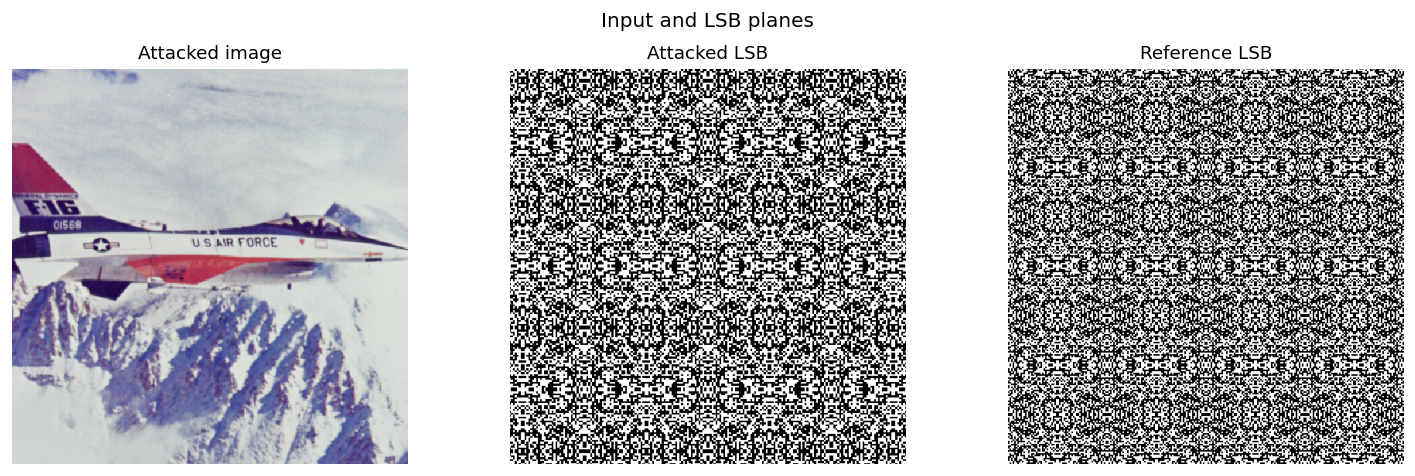

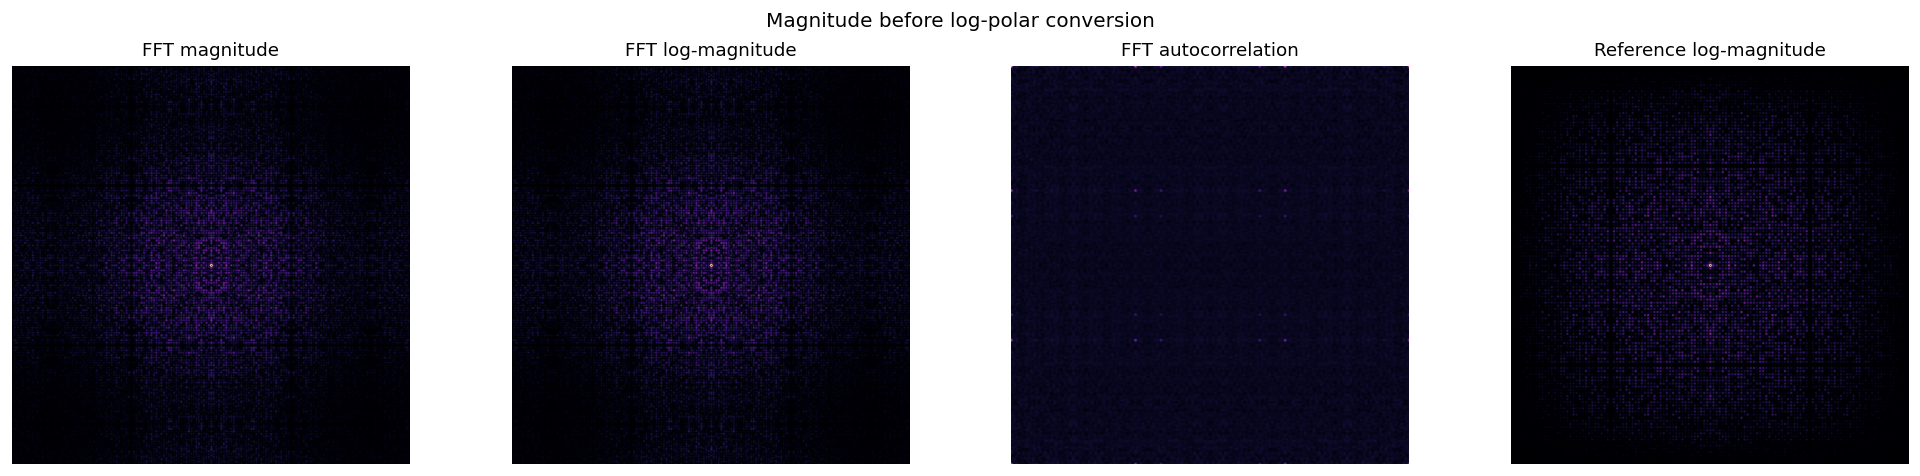

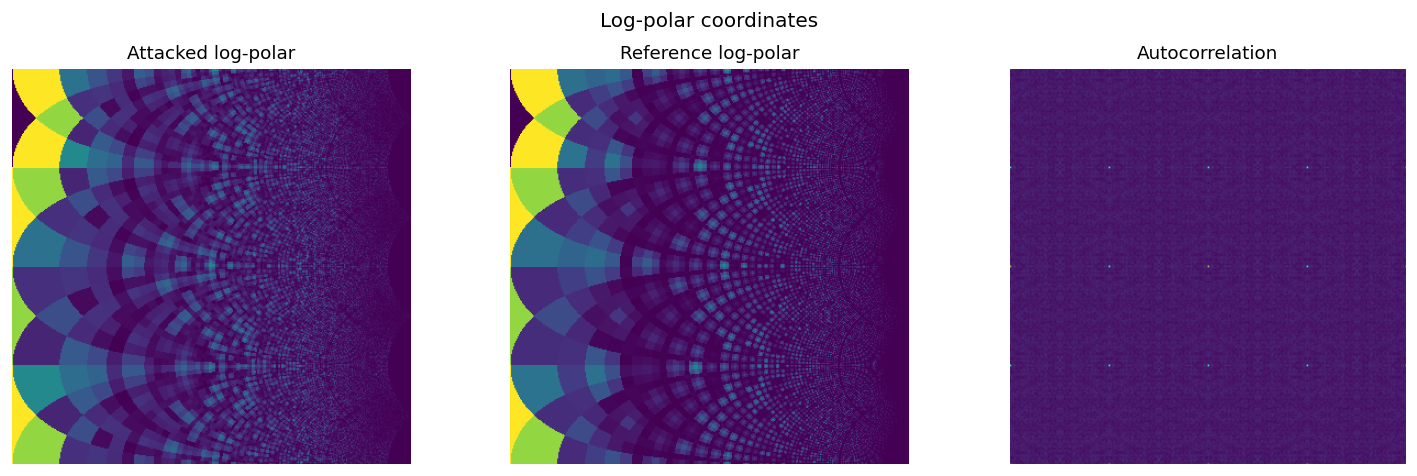

Log-polar phase shift: row=0.0030, col=0.0030
Estimated angle: 0.0030 deg
Estimated scale: 1.000046


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
from skimage.filters import window
from skimage.registration import phase_cross_correlation
from skimage.transform import warp_polar
from utils.sync import correct_rotation_scale, correct_translation, estimate_translation, synchronise

debug_image_name = 'airplane' if 'airplane' in images else next(iter(images))
debug_attack_name = 'crop_10pct'
print(f'Debug image: {debug_image_name}')
print(f'Debug attack: {debug_attack_name}')

debug_src = to_u8(images[debug_image_name])
debug_wm = model.encode(debug_src, watermark)
debug_attacked = to_u8(ATTACKS[debug_attack_name](debug_wm))
debug_attacked_lsb = extract_lsb_plane(debug_attacked)

debug_reference_lsb = build_reference_patch(
    debug_attacked_lsb.shape,
    patch_size=model.patch_size,
    key=model.key,
    tile_mode=model.tile_mode,
)

def debug_fourier_mellin_spectrum(image: np.ndarray) -> dict[str, np.ndarray]:
    image_f = img_as_float64(image)
    win = window('hann', image_f.shape)
    windowed = image_f * win
    autocorrelation = np.fft.ifft2(np.fft.fft2(image_f) * np.conj(np.fft.fft2(image_f))).real
    fft_shifted = np.fft.fftshift(np.fft.fft2(windowed))
    magnitude = np.abs(fft_shifted) 
    magnitude[magnitude.shape[0] // 2, magnitude.shape[1] // 2] = 0.0
    log_mag = np.log1p(magnitude)
    lo, hi = log_mag.min(), log_mag.max()
    if hi > lo:
        log_mag = (log_mag - lo) / (hi - lo)
    log_polar = warp_polar(log_mag, scaling='log', order=0)
    return {
        'windowed': windowed,
        'magnitude': magnitude,
        'autocorrelation': autocorrelation,
        'log_mag': log_mag,
        'log_polar': log_polar,
    }

def show_panel(images_to_show: list[tuple[str, np.ndarray]], title: str, cmap: str = 'gray', vmin=None, vmax=None) -> None:
    fig, axes = plt.subplots(1, len(images_to_show), figsize=(4.2 * len(images_to_show), 4))
    axes = np.atleast_1d(axes)
    for ax, (panel_title, panel_img) in zip(axes, images_to_show):
        ax.imshow(panel_img, cmap=cmap)
        ax.set_title(panel_title)
        ax.axis('off')
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

att_dbg = debug_fourier_mellin_spectrum(debug_attacked_lsb)
ref_dbg = debug_fourier_mellin_spectrum(debug_reference_lsb)

show_panel(
    [
        ('Attacked image', debug_attacked),
        ('Attacked LSB', debug_attacked_lsb),
        ('Reference LSB', debug_reference_lsb),
    ],
    title='Input and LSB planes',
    cmap='gray',
)

show_panel(
    [
        ('FFT magnitude', np.log1p(att_dbg['magnitude'])),
        ('FFT log-magnitude', att_dbg['log_mag']),
        ('FFT autocorrelation', att_dbg['autocorrelation']),
        ('Reference log-magnitude', ref_dbg['log_mag']),
    ],
    title='Magnitude before log-polar conversion',
    cmap='magma',
)

show_panel(
    [
        ('Attacked log-polar', att_dbg['log_polar']),
        ('Reference log-polar', ref_dbg['log_polar']),
        ('Autocorrelation', ref_dbg['autocorrelation']),
    ],
    title='Log-polar coordinates',
    cmap='viridis',
)

shift, _, _ = phase_cross_correlation(
    ref_dbg['log_polar'],
    att_dbg['log_polar'],
    normalization=None,
    upsample_factor=model.upsample_factor_rs,
)
H, W = att_dbg['log_polar'].shape
estimated_angle = float(shift[0] / H * 360.0)
r_max = np.sqrt(H**2 + W**2) / 2.0
estimated_scale = float(np.exp(shift[1] / W * np.log(max(r_max, 2.0))))

print(f'Log-polar phase shift: row={shift[0]:.4f}, col={shift[1]:.4f}')
print(f'Estimated angle: {estimated_angle:.4f} deg')
print(f'Estimated scale: {estimated_scale:.6f}')

candidate_rows = []
for candidate_angle in [estimated_angle, estimated_angle + 180.0]:
    corrected_rs = correct_rotation_scale(debug_attacked_lsb, candidate_angle, estimated_scale)
    dr, dc, error = estimate_translation(
        corrected_rs,
        upsample_factor=model.upsample_factor_t,
        key=model.key,
        patch_size=model.patch_size,
        tile_mode=model.tile_mode,
    )
    candidate_rows.append((candidate_angle, corrected_rs, dr, dc, error))
    print(
        f'Candidate angle={candidate_angle:.4f} deg | translation=({dr:.4f}, {dc:.4f}) | phase error={error:.6f}'
    )

best_angle, best_rs, best_dr, best_dc, best_error = min(candidate_rows, key=lambda item: item[4])
aligned_stepwise = correct_translation(best_rs, best_dr, best_dc)
aligned_full = synchronise(
    debug_attacked_lsb,
    upsample_factor_rs=model.upsample_factor_rs,
    upsample_factor_t=model.upsample_factor_t,
    patch_size=model.patch_size,
    key=model.key,
    tile_mode=model.tile_mode,
)

print(f'Selected angle: {best_angle:.4f} deg')
print(f'Selected translation: ({best_dr:.4f}, {best_dc:.4f})')
print(f'Selected phase error: {best_error:.6f}')
print(f'Stepwise vs synchronise max abs diff: {np.nanmax(np.abs(aligned_stepwise - aligned_full)):.6f}')

show_panel(
    [
        ('Best RS-corrected LSB', best_rs),
        ('Stepwise aligned LSB', aligned_stepwise),
        ('synchronise() result', aligned_full),
    ],
    title='Rotation/scale correction and final alignment',
    cmap='gray',
    vmin=0,
    vmax=1,
)